# Chapter 1: Radiative Transfer — The Physical Forward Model
### Bayesian Remote Sensing Curriculum

The forward model F(x) is the radiative transfer equation. Before we can do any
Bayesian retrieval, we need to understand what the satellite actually measures.

This notebook builds:
1. The Planck function — thermal emission at any temperature
2. Beer-Lambert law and optical depth
3. Simplified 1D thermal IR radiance calculation
4. Weighting functions — where in the atmosphere do different channels "see"?
5. AOD spectral dependence — the Ångström exponent


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, constants

# Physical constants
h   = constants.h          # Planck constant [J·s]
c   = constants.c * 100    # Speed of light [cm/s]
kB  = constants.k          # Boltzmann constant [J/K]
c1  = 2 * h * c**2         # First radiation constant
c2  = h * c / kB           # Second radiation constant [cm·K]

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
print(f"c2 = h*c/k = {c2:.2f} cm·K")
print(f"Wien peak for T=250 K: nu_peak = 1.96 * T / c2 = {1.96*250/c2:.0f} cm-1")


c2 = h*c/k = 1.44 cm·K
Wien peak for T=250 K: nu_peak = 1.96 * T / c2 = 341 cm-1


## 1.1 The Planck Function

The spectrum of thermal emission at temperature T:

$$B(\nu, T) = \frac{2hc^2\nu^3}{\exp(hc\nu/kT) - 1} \tag{1}$$

This is what the atmosphere and surface emit. The satellite measures the
radiance reaching the top of the atmosphere — a mixture of surface emission
and atmospheric emission at various temperatures.


In [1]:
# # Calcualting derivative of B with respect to T using sympy just like mathematica
# import sympy as sp

# # define symbols
# nu1, T1, c11, c21 = sp.symbols('nu1 T1 c11 c21', positive=True)

# # define Planck function
# B1 = c11 * nu1**3 / (sp.exp(c21*nu1/T) - 1)

# # derivative with respect to T
# dB1dT1 = sp.diff(B1, T1)

# print("Derivative:")
# sp.pprint(dB1dT1)

Equation -1 

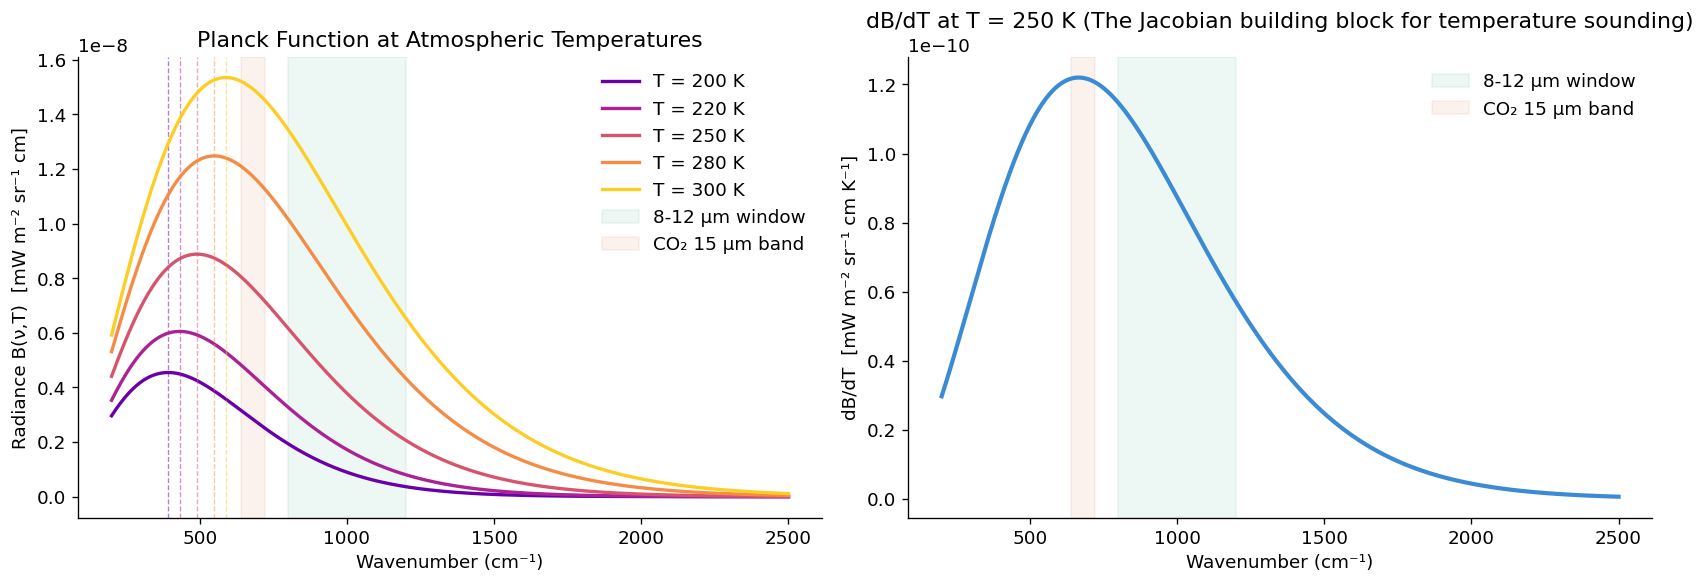

Planck function at key channels:
  900 cm-1 (window),  T=290K:  B = 0.01 mW m-2 sr-1 cm
  667 cm-1 (CO2 core), T=250K: B = 0.01 mW m-2 sr-1 cm


In [2]:
# Planck function ===> equation 1
def planck(nu, T):
    return c1 * nu**3 / (np.expm1(c2 * nu / T))

nu = np.linspace(200, 2500, 2000)   # wavenumber (cm-1)
temps = [200, 220, 250, 280, 300]
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(temps)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full spectrum
for T, col in zip(temps, colors):
    B = planck(nu, T) * 1e-3   # to mW m-2 sr-1 cm
    axes[0].plot(nu, B, color=col, lw=2, label=f"T = {T} K")
    # Mark peak
    nu_peak = nu[np.argmax(B)]
    axes[0].axvline(nu_peak, color=col, lw=0.8, ls="--", alpha=0.5)

axes[0].set_xlabel("Wavenumber (cm⁻¹)")
axes[0].set_ylabel("Radiance B(ν,T)  [mW m⁻² sr⁻¹ cm]")
axes[0].set_title("Planck Function at Atmospheric Temperatures")
axes[0].legend(frameon=False)

# Spectral derivative dB/dT — important for Jacobians
for T, col in zip([250], ["#3B8BD4"]):
    dBdT = c1 * nu**3 * c2 * nu / T**2 / (np.expm1(c2*nu/T)**2) * np.exp(c2*nu/T)
    dBdT *= 1e-3
    axes[1].plot(nu, dBdT, color=col, lw=2.5)
    axes[1].set_title("dB/dT at T = 250 K (The Jacobian building block for temperature sounding)")
    axes[1].set_xlabel("Wavenumber (cm⁻¹)")
    axes[1].set_ylabel("dB/dT  [mW m⁻² sr⁻¹ cm K⁻¹]")

# Mark key atmospheric windows and absorption bands
for ax in axes:
    ax.axvspan(800, 1200, color="#1D9E75", alpha=0.08, label="8-12 μm window") # greenish background for the band
    ax.axvspan(640, 720, color="#D85A30", alpha=0.08, label="CO₂ 15 μm band") # redish background  for the band

# Add legends after spans
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Brightness temperature conversion
def rad_to_BT(nu, B):
    return c2 * nu / np.log(1 + c1 * nu**3 / B)

print("Planck function at key channels:")
print(f"  900 cm-1 (window),  T=290K:  B = {planck(900,290)*1e3:.2f} mW m-2 sr-1 cm")
print(f"  667 cm-1 (CO2 core), T=250K: B = {planck(667,250)*1e3:.2f} mW m-2 sr-1 cm")


## 1.2 Beer-Lambert Law and Optical Depth

Radiation attenuates exponentially through an absorbing medium:

$$I(L) = I_0 \cdot e^{-\tau}, \quad \tau = \int_0^L k_{\text{abs}}(s)ds$$

The **transmittance** $T = e^{-\tau}$ ranges from 0 (opaque) to 1 (transparent). Let's learn more about the $\tau$ and $T$.

---

## Simplified Atmospheric Transmittance Model

Below we will learn a **simplified infrared atmospheric transmittance spectrum** between **500–800 cm⁻¹**. The goal is to illustrate how atmospheric gases such as **CO₂ and H₂O absorb thermal radiation** and how this absorption affects the radiation observed by satellites. The model is intentionally simplified and designed for **visualization and educational purposes**, not for accurate radiative transfer calculations.

1. **Optical Depth (τ):** In atmospheric radiative transfer, the absorption of radiation along a path is described by the **optical depth** ( \tau ). Optical depth measures how strongly radiation is attenuated by absorbing gases along the path through the atmosphere.

    $$
    \tau(\nu) = \int_0^s k(\nu,z)\rho(z),dz 
    $$

    where:

    * $ \nu $ : spectral wavenumber (cm⁻¹)
    * $ k(\nu,z) $ : absorption coefficient of the gas
    * $ \rho(z) $ : absorber density
    * $ z $ : altitude
    * $s$ : path length through the atmosphere

    Large values of $ \tau $ indicate strong absorption, while small values correspond to weak absorption. So it is clear that $\tau$ depends on the vertical distribution of gas and the spectral absorption coefficient.

    2. **Absorption coefficient from spectral lines:** Real molecular absorption is produced by **discrete spectral lines**.

    The absorption coefficient is

    $$
    k(\nu)=\sum_i S_i , g_i(\nu-\nu_i)
    $$

    where

    * $S_i$ = line strength
    * $\nu_i$ = line center
    * $g_i$ = line shape function

    Line shapes come from physical broadening processes:


<table style="border-collapse: collapse; width: 50%; text-align: left;">
  <tr style="background-color: #f2f2f2;">
    <th style="border: 1px solid #ddd; padding: 8px;">Broadening</th>
    <th style="border: 1px solid #ddd; padding: 8px;">Shape</th>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Doppler (thermal)</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Gaussian</td>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Pressure broadening</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Lorentzian</td>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Combined</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Voigt</td>
  </tr>
</table>

Real atmospheric models (HITRAN, LBLRTM) compute **thousands of lines** this way. Instead of summing thousands of lines, we can approximates the **entire absorption band** using a single Gaussian envelope:

$$
\tau(\nu)=A \exp\left(-\frac{(\nu-\nu_0)^2}{2\sigma^2}\right)
$$

This is **not a derivation**. It is just a **smooth approximation of a spectral band**.

3. **Beer–Lambert Law:** Radiation passing through an absorbing medium follows the **Beer–Lambert law**:

    $$
    T(\nu) = e^{-\tau(\nu)} \tag{2}
    $$

    where:

    * $T(\nu)$ = atmospheric **transmittance**
    * $\tau(\nu)$ = **optical depth**

    Interpretation:

    * $T \approx 1$ → atmosphere is transparent
    * $T \approx 0$ → atmosphere is opaque

    This relationship is widely used in **remote sensing, spectroscopy, and atmospheric physics**.

4. **Spectral Absorption by Atmospheric Gases:** Different gases absorb radiation at specific wavelengths determined by their molecular structure.

    - **CO₂ absorption:** Carbon dioxide has a strong **vibrational absorption band near 15 μm**, corresponding to approximately:

    $$
    \nu \approx 667 , cm^{-1}
    $$

    This band dominates the thermal infrared spectrum and is widely used for **temperature sounding in satellite instruments**.

    - **H₂O absorption:** Water vapor exhibits many rotational-vibrational absorption lines in the infrared. In this simplified model, a broad absorption feature near **750 cm⁻¹** is used to represent water vapor absorption.


5. **Simplified Spectral Model:** In reality, atmospheric absorption consists of **thousands of individual spectral lines** described by line-by-line radiative transfer models such as:

    * HITRAN
    * LBLRTM
    * MODTRAN

    For simplicity, this demonstration approximates absorption bands using **Gaussian functions**.

    - **CO₂ optical depth:**

    $$
    \tau_{CO_2}(\nu) =
    A_{CO_2} \exp
    \left(
    -\frac{(\nu-\nu_{CO_2})^2}{2\sigma^2}
    \right) \tag{3}
    $$

    where:

    * $ \nu_{CO_2} = 667,cm^{-1} $
    * $ \sigma = 15,cm^{-1} $
    * $ A_{CO_2} = 8 $

    These values for the ampltitude and width were chosen simply so the band looks strongly opaque.

    - **H₂O optical depth:**

    $$
    \tau_{H_2O}(\nu) =
    A_{H_2O} \exp
    \left(
    -\frac{(\nu-\nu_{H_2O})^2}{2\sigma^2}
    \right) \tag{4}
    $$

    where:

    * $\nu_{H_2O} = 750,cm^{-1} $
    * $ \sigma = 30,cm^{-1} $
    * $ A_{H_2O} = 2 $

    These Gaussian profiles are **not derived from first principles**. They are simply **smooth approximations used to mimic the shape of real absorption bands**.

6. **Total Optical Depth:** Since different gases absorb independently, the total optical depth is approximated as:

    $$
    \tau_{total} =
    \tau_{CO_2} + \tau_{H_2O} + \tau_{\rm background}
    $$

    A small constant term is added to represent weak background absorption.

7. **Transmittance Spectrum:** The final atmospheric transmittance spectrum is computed using:

    $$
    T(\nu) = e^{-\tau_{total}(\nu)} \tag{5}
    $$

    This produces a spectrum where:

    * Deep minima correspond to **strong absorption bands**
    * High values correspond to **spectral windows**

---

**Note:** The equations used here were **not invented for this code**. They are simplified representations based on well-known physical principles:

* Beer–Lambert law
* Molecular absorption spectroscopy
* Radiative transfer theory

However, the **specific Gaussian parameters** used here are only illustrative and do not represent real atmospheric spectra.

For realistic simulations, line-by-line radiative transfer models and spectroscopic databases such as **HITRAN** are required.


**Purpose of the Model** This simplified model helps visualize:

* how optical depth affects radiation transmission
* how different gases shape the infrared spectrum
* why certain spectral regions are opaque or transparent

Such concepts are fundamental in **satellite remote sensing**, **climate physics**, and **atmospheric sounding**.

---

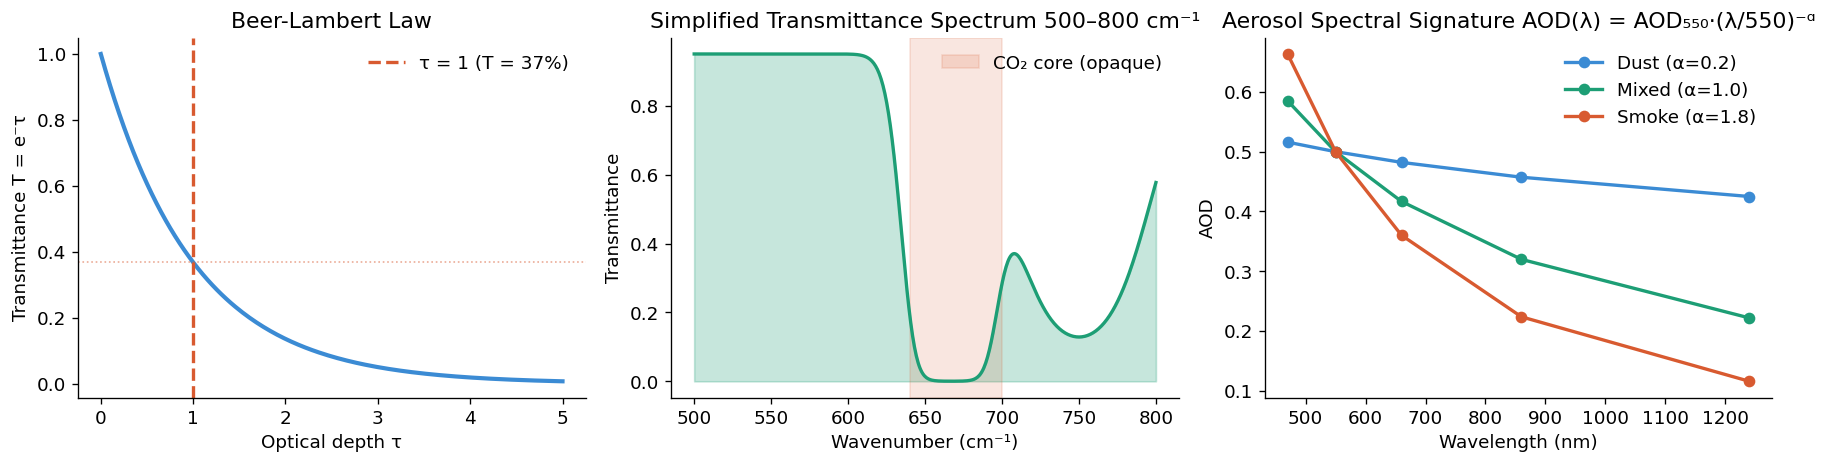

In [3]:
# Beer-Lambert: transmittance through different optical depths 
tau_values = np.linspace(0, 5, 200)
transmittance = np.exp(-tau_values) # equation -2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(tau_values, transmittance, "#3B8BD4", lw=2.5)
axes[0].axvline(1.0, color="#D85A30", lw=2, ls="--", label="τ = 1 (T = 37%)")
axes[0].axhline(1/np.e, color="#D85A30", lw=1, ls=":", alpha=0.5)
axes[0].set_xlabel("Optical depth τ"); axes[0].set_ylabel("Transmittance T = e⁻τ")
axes[0].set_title("Beer-Lambert Law")
axes[0].legend(frameon=False)

# Absorption spectrum — simplified CO2 + H2O profile
nu_fine = np.linspace(500, 800, 500) # np.linspace(start, stop, number_of_points)
# Simulate a simplified absorption spectrum 
# tau_totoal = tau_CO2+ tau_H2O
tau_co2 = 8 * np.exp(-((nu_fine - 667)**2)/(2*15**2))      # CO2 15um band         ---->  equation 3
tau_h2o = 2 * np.exp(-((nu_fine - 750)**2)/(2*30**2))      # H2O rotation band     ---->  equation 4
tau_total = tau_co2 + tau_h2o + 0.05                       # add window absorption ---->  equation 5

T_spec = np.exp(-tau_total)
axes[1].plot(nu_fine, T_spec, "#1D9E75", lw=2)
axes[1].fill_between(nu_fine, T_spec, alpha=0.25, color="#1D9E75")
axes[1].axvspan(640, 700, color="#D85A30", alpha=0.15, label="CO₂ core (opaque)")
axes[1].set_xlabel("Wavenumber (cm⁻¹)"); axes[1].set_ylabel("Transmittance")
axes[1].set_title("Simplified Transmittance Spectrum 500–800 cm⁻¹")
axes[1].legend(frameon=False)

# AOD vs wavelength: Ångström exponent ======> Read the Readme file
lambda_nm = np.array([470, 550, 660, 860, 1240])
AOD_550 = 0.5
alphas = [0.2, 1.0, 1.8]   # different aerosol types

# semilogy(x,y) plot where:
#   x-axis → linear scale
#   y-axis → logarithmic scale

for alpha, col, label in zip(alphas, ["#3B8BD4","#1D9E75","#D85A30"], ["Dust (α=0.2)", "Mixed (α=1.0)", "Smoke (α=1.8)"]):
    AOD = AOD_550 * (lambda_nm / 550)**(-alpha)
    # axes[2].semilogy(lambda_nm, AOD, 'o-', color=col, lw=2, label=label) #---> for semilog
    axes[2].plot(lambda_nm, AOD, 'o-', color=col, lw=2, label=label)       # --> normal plot

axes[2].set_xlabel("Wavelength (nm)"); axes[2].set_ylabel("AOD")
axes[2].set_title("Aerosol Spectral Signature AOD(λ) = AOD₅₅₀·(λ/550)⁻ᵅ")
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()


## 1.3 Simplified Thermal IR Radiance Profile

A nadir-viewing satellite observes:

$$
I_\text{TOA}(\nu) = \varepsilon_s B(\nu, T_s) t(\nu, p_s) + \int_0^{p_s} B(\nu, T(p)) \frac{\partial t(\nu, p)}{\partial p}\, dp \tag{6}
$$ 

Here first term is related to surface emission and the second is the atmospheric emission contribution. 

Let's build this for a 10-level atmosphere. But for that, let's first understand few important topics:

1. **vertical temperature profile:** The vertical temperature profile is based on the concept of the atmospheric lapse rate, which describes how temperature changes with altitude. In the troposphere, temperature typically decreases approximately linearly with height. The lapse rate is defined as the vertical temperature gradient

    $$
    \Gamma = -\frac{dT}{dz}
    $$

    where $T$ is temperature and $z$ is altitude. Observations of the Earth's atmosphere show that the average environmental lapse rate in the troposphere is about

    $$
    \Gamma \approx 6.5 ; K,km^{-1}.
    $$

    If the lapse rate is assumed to be approximately constant over the troposphere, the differential relation can be integrated. Starting from

    $$
    \frac{dT}{dz} = -\Gamma
    $$

    and integrating with respect to altitude gives

    $$
    T(z) = T_0 - \Gamma z \tag{7}
    $$

    where $T_0$ is the temperature at the reference level, typically the surface. For a standard atmosphere the reference surface temperature is taken to be

    $$
    T_0 \approx 288,K.
    $$

    Substituting the observed lapse rate gives the commonly used appr

2. **Relation between the altitude and pressure:** The relation between altitude and pressure comes from combining the hydrostatic balance of the atmosphere with the ideal gas law. In a vertically stratified atmosphere the pressure decreases with height because each layer must support the weight of the air above it. This balance is described by the hydrostatic equation

    $$
    \frac{dP}{dz} = -\rho g
    $$

    where $P$ is pressure, $z$ is altitude, $\rho$ is air density, and $g$ is gravitational acceleration. The negative sign indicates that pressure decreases as altitude increases. To eliminate density, the ideal gas law for air is used $P = \rho R T$, where $R$ is the specific gas constant for dry air and $T$ is temperature. Solving this expression for density gives

    $$
    \rho = \frac{P}{RT} 
    $$

    Substituting this into the hydrostatic equation yields

    $$
    \frac{dP}{dz} = -\frac{Pg}{RT} \Rightarrow \frac{dP}{P} = -\frac{g}{RT}dz.
    $$

    If temperature is assumed to be approximately constant with height over the layer considered, the equation can be integrated between a reference pressure $P_0$ at altitude $z=0$ and a pressure $P$ at altitude $z$

    $$
    \int_{P_0}^{P} \frac{dP}{P}= -\frac{g}{RT}\int_{0}^{z} dz \Rightarrow \ln\left(\frac{P}{P_0}\right) = -\frac{gz}{RT}.
    $$

    Solving for altitude gives

    $$
    z = \frac{RT}{g}\ln\left(\frac{P_0}{P}\right).
    $$

    The factor

    $$
    H = \frac{RT}{g}
    $$

    is called the atmospheric scale height. For typical atmospheric conditions with $T \approx 280 K$, $R = 287 Jkg^{-1}K^{-1}$, and $g = 9.81 ms^{-2}$, the scale height is approximately

    $$
    H \approx 8 km.
    $$

    This gives the approximate relation

    $$
    z \approx H \ln\left(\frac{P_0}{P}\right). \tag{8}
    $$

3. **Pressure dependent absorption coefficient:** First remember what the absorption coefficient represents. In radiative transfer the extinction of radiation along a path is written as $d\tau = k_\nu  ds$, where $k_\nu$ is the **absorption coefficient** and $\tau$ is optical depth. For molecular gases the absorption coefficient depends on

    * the number of absorbing molecules
    * the spectral line shape
    
    It can be written approximately as

    $$
    k_\nu = n \sigma_\nu
    $$

    where

    - $n$ = number density of molecules
    - $\sigma_\nu$ = absorption cross section.

    Now consider how **number density depends on pressure**. From the ideal gas law $P = n k_B T$, so

    $$
    n = \frac{P}{k_B T}.
    $$

    If temperature does not vary strongly within a layer, the number of molecules is approximately proportional to pressure:

    $$
    n \propto P.
    $$

    This means the basic absorption coefficient scales with pressure.

    The second effect is **pressure broadening (collision broadening)**. Molecular spectral lines are not infinitely narrow. Collisions between molecules disturb energy levels and broaden the line profile. The Lorentz line width for pressure broadening is approximately

    $$
    \gamma_L \propto P.
    $$

    A simplified Lorentz line shape can be written as

    $$
    g(\nu) = \frac{\gamma_L}{(\nu-\nu_0)^2 + \gamma_L^2}.
    $$

    As pressure increases, the line becomes wider. When we observe radiation with a finite spectral channel width (as satellites do), broader lines effectively increase the **integrated absorption across the channel**.

    Therefore the effective absorption coefficient in a channel grows with pressure because

    1. **more molecules are present** $(n \propto P)$
    2. **spectral lines broaden with collisions** $(\gamma_L \propto P)$

    Combining these effects leads to the simplified scaling

    $$
    k_\nu(p) \propto P.
    $$

    Therefore pressure dependeint $k(p)$ can be written as:

    $$
    k(p) = k_{abs} \frac{p}{1013}. \tag{9}
    $$

    Here

    * $k_{abs}$ is a constant representing the channel’s absorption strength
    * $1013 \text{hPa}$ is the approximate surface pressure used to normalize the profile.

    So the model assumes

    * strong absorption near the surface where pressure is high
    * weaker absorption at high altitude where pressure is low.

    This is not a full spectroscopic calculation, but it captures the **correct qualitative behavior of atmospheric absorption with altitude**, which is enough to produce realistic weighting functions for the demonstration.


4. **Atmospheric weighting functions:** The concept of atmospheric weighting functions, which describe how radiation measured by a satellite originates from different atmospheric layers. Satellite infrared instruments do not measure temperature directly. Instead, they measure radiance at the top of the atmosphere, and this radiance results from emission by the surface and by atmospheric layers along the line of sight.

    The propagation of radiation through the atmosphere is governed by the radiative transfer equation. For a plane-parallel atmosphere in local thermodynamic equilibrium and neglecting scattering, the upward radiance observed at the top of the atmosphere can be written as

    $$
    I_\nu(TOA) = B_\nu(T_s) t_\nu(0) + \int_0^\infty B_\nu(T(z)) \frac{d t_\nu(z)}{dz}dz
    $$

    where $I_\nu$ is the spectral radiance at frequency (or wavenumber) $\nu$, $B_\nu(T)$ is the Planck function describing thermal emission at temperature $T$, $T_s$ is the surface temperature, and $t_\nu(z)$ is the atmospheric transmittance between altitude $z$ and space.

    The transmittance is related to the optical depth through the Beer–Lambert relation

    $$
    t_\nu(z) = e^{-\tau_\nu(z)}
    $$

    where $\tau_\nu(z)$ represents the integrated absorption between altitude $z$ and the top of the atmosphere. The optical depth depends on the concentration of absorbing gases and their absorption coefficients. It is defined as

    $$
    \tau = \int k , ds
    $$

    In pressure coordinates this becomes approximately

    $$
    \tau(p) \approx \sum k(p)\Delta p \tag{10}
    $$

    The code computes the **cumulative optical depth from a level to space**.

    $$
    \tau(p) =
    \int_p^{TOA} k(p')dp'
    $$

    Usually this integral is performed inversasly which makes the integration go **from top of atmosphere downward**.

    Differentiating the transmittance with respect to altitude gives a quantity that describes how strongly each atmospheric layer contributes to the outgoing radiance. This quantity is called the weighting function

    $$
    W_\nu(z) = -\frac{d t_\nu(z)}{dz}.\tag{11}
    $$

    Substituting this definition into the radiative transfer expression yields

    $$
    I_\nu(TOA) = B_\nu(T_s) t_\nu(0) + \int_0^\infty B_\nu(T(z)) W_\nu(z)dz. \tag{12}
    $$

    The weighting function therefore acts as a vertical sensitivity function that determines the relative contribution of each atmospheric level to the measured radiance. Layers where the weighting function is large contribute strongly to the signal observed by the satellite.

    The shape of the weighting function depends primarily on atmospheric absorption at the chosen wavelength. If absorption is weak, the atmosphere is transparent and radiation from the surface dominates the signal. In this case the weighting function peaks near the surface. If absorption is stronger, radiation from lower layers is absorbed before reaching space, and the peak of the weighting function shifts upward into the atmosphere.

    Strong absorption bands, such as the core of the carbon dioxide band near $667,cm^{-1}$, produce weighting functions that peak in the upper troposphere or stratosphere. Weaker absorption regions, such as atmospheric window channels around $900,cm^{-1}$, produce weighting functions that peak near the surface. Channels located on the flanks of absorption bands typically sense intermediate atmospheric layers.

    Because each spectral channel has a different weighting function, satellite instruments measuring many wavelengths can sample radiation from multiple atmospheric heights. This property forms the basis of atmospheric temperature sounding used by infrared satellite instruments.

```py
p_levels = [1000, 900, 800]
np.diff(p_levels) = [-100,100]
```
length N-1. However with prepend is used to add the first elememnts at the beginning before computing difference. So
```py
np.diff(p_levels, prepend=p_levels[0])
```
This adds the first element at the beginning before computing differences: 
```py
p_values= [1000, 1000, 900,800] = [0,-100,-100]
```
same lenght `p_values`.

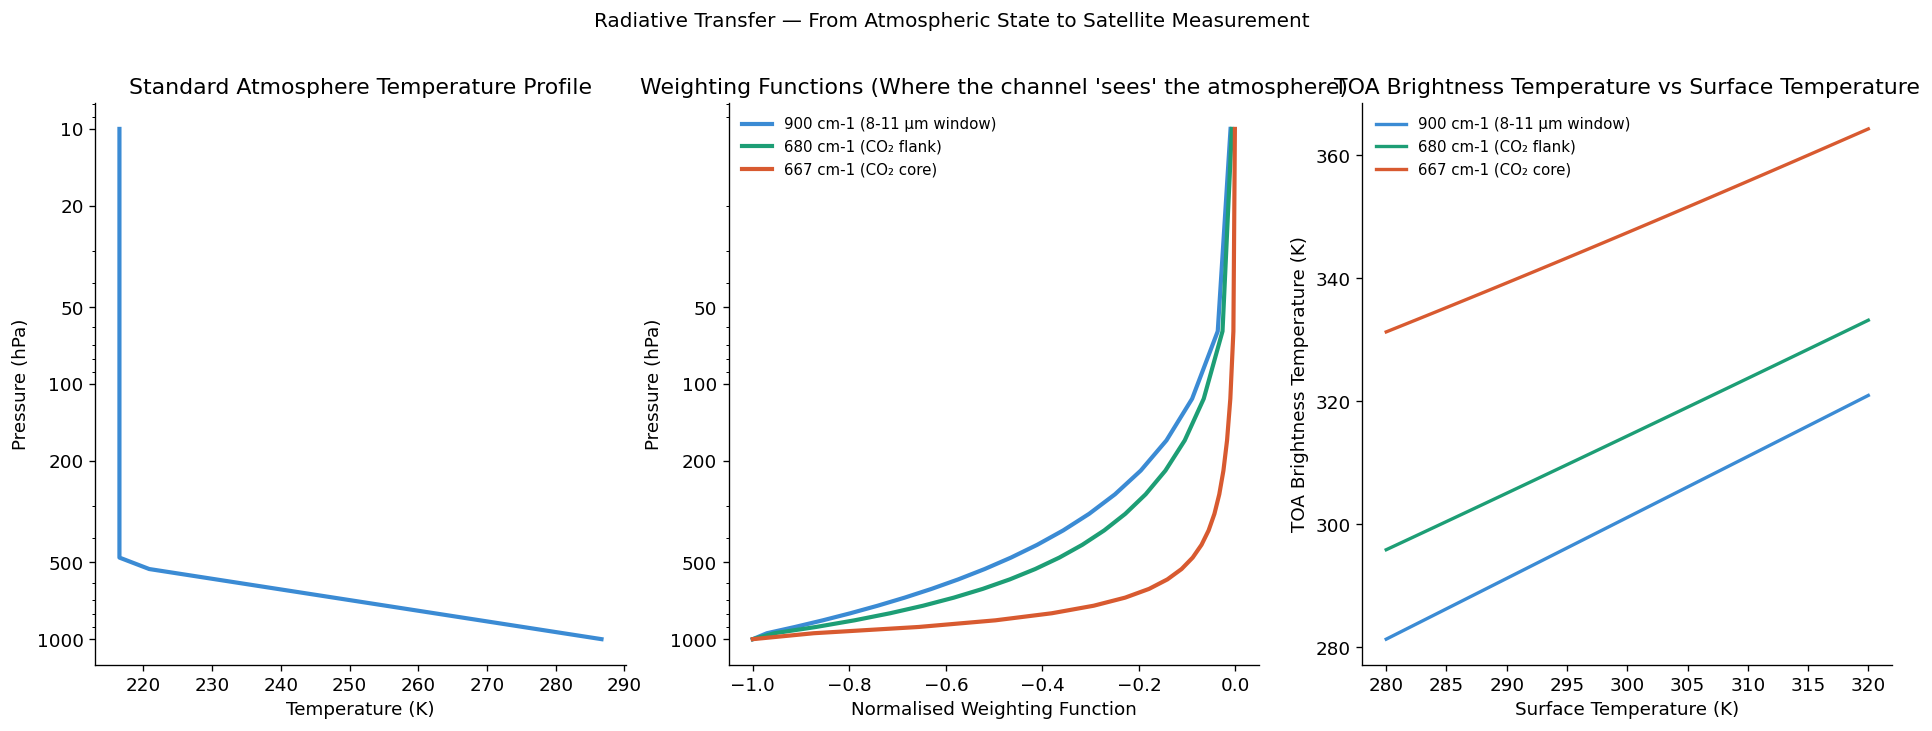

Key insight: The window channel BT tracks surface T closely.
The CO2 core channel is nearly insensitive to surface T — it sees the stratosphere.


In [4]:
# Simplified 10-level atmosphere — compute TOA brightness temperatures
n_levels = 20
p_levels = np.linspace(1000, 10, n_levels)                                     # pressure (hPa)
z_approx = 16 * np.log(1013/p_levels)                                          # approx height (km)          ====> equation 8

T_std = 288 - 6.5 * z_approx                                                   # troposphere lapse rate      =====> equation 7
# T_std = np.clip(T_std, 215, 300)                                             # clamp to realistic rangen =====> 215 < T < 300 ===> this can also be written as:
T_std = np.where(z_approx < 11, 288 - 6.5*z_approx, 216.5)                     # np.where(condition, value_if_true, value_if_false)
# The simple linear formula is only valid in the troposphere therefore, we need to clip the temperature
# If T<215, it becomes 215 K
# If T>300, it becomes 300 K

# Simulate at 3 channels: window, CO2 flank, CO2 core
channels = {
    "900 cm-1 (8-11 μm window)":  (900, 0.08),                           # nu and k_abs
    "680 cm-1 (CO₂ flank)":       (680, 0.8),
    "667 cm-1 (CO₂ core)":        (667, 5.0),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
ax_T, ax_wf, ax_bt = axes

# Temperature profile                                                          # =======> 7 + 8 combined
ax_T.plot(T_std, p_levels, "#3B8BD4", lw=2.5)
ax_T.invert_yaxis()
ax_T.set_yscale("log")
ax_T.set_xlabel("Temperature (K)")
ax_T.set_ylabel("Pressure (hPa)")
ax_T.set_title("Standard Atmosphere Temperature Profile")
ax_T.set_yticks([1000, 500, 200, 100, 50, 20, 10])
ax_T.set_yticklabels(["1000","500","200","100","50","20","10"])

colors_ch = ["#3B8BD4", "#1D9E75", "#D85A30"]

for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    # Build transmittance profile: t(p) = exp(-tau(p))
    # tau(p) = column absorption from p to TOA
    # k_abs proportional to pressure (collision broadening)
    k_profile = k_abs_col * p_levels / 1013.0                                  # ========> equation 9
    dp = np.diff(p_levels, prepend=p_levels[0])                                
    # np.diff(array) computes differences between consecutive elements ==> diff(p)_i = p_i - p_{i-1}
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]                 # ========> equation 10 
    # here [::-1] makes the integration go from top of atmosphere downward.
    t_profile = np.exp(-tau_cum[::-1])

    # Weighting function: dt/dp (where does the signal come from?)
    dt_dp = np.gradient(t_profile, p_levels)                                   # ========>  equation 11

    ax_wf.plot(-dt_dp / np.abs(-dt_dp).max(), p_levels, color=col, lw=2.5, label=ch_name)

    # TOA brightness temperature
    B_surface = planck(nu_ch, 295)   # surface emission at T=295 K
    B_atm     = planck(nu_ch, T_std)  # atmospheric emission at each level
    I_TOA = B_surface * t_profile[0]  + np.trapezoid(B_atm * (-np.gradient(t_profile, p_levels)), p_levels) # =====> equation 12
    # t_profile[0] ==1 means atmosphere transparent (window region)
    BT = rad_to_BT(nu_ch, I_TOA)

ax_wf.invert_yaxis()
ax_wf.set_yscale("log")
ax_wf.set_xlabel("Normalised Weighting Function")
ax_wf.set_ylabel("Pressure (hPa)")
ax_wf.set_title("Weighting Functions (Where the channel 'sees' the atmosphere)")
ax_wf.legend(frameon=False, fontsize=9)
ax_wf.set_yticks([1000, 500, 200, 100, 50])
ax_wf.set_yticklabels(["1000","500","200","100","50"])

# TOA BT as function of surface temperature perturbation
T_surface = np.linspace(280, 320, 50)
ax_bt.set_title("TOA Brightness Temperature vs Surface Temperature")
for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):
    BTs = []
    for Ts in T_surface:
        B_s = planck(nu_ch, Ts)
        k_profile = k_abs_col * p_levels / 1013.0
        dp = np.diff(p_levels, prepend=p_levels[0])
        tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
        t_p = np.exp(-tau_cum[::-1])
        B_atm = planck(nu_ch, T_std)
        I_TOA = B_s * t_p[0] + np.trapezoid(B_atm * (-np.gradient(t_p, p_levels)), p_levels)
        BTs.append(rad_to_BT(nu_ch, I_TOA))
    ax_bt.plot(T_surface, BTs, color=col, lw=2, label=ch_name)

ax_bt.set_xlabel("Surface Temperature (K)")
ax_bt.set_ylabel("TOA Brightness Temperature (K)")
ax_bt.legend(frameon=False, fontsize=9)

plt.suptitle("Radiative Transfer — From Atmospheric State to Satellite Measurement", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Key insight: The window channel BT tracks surface T closely.")
print("The CO2 core channel is nearly insensitive to surface T — it sees the stratosphere.")


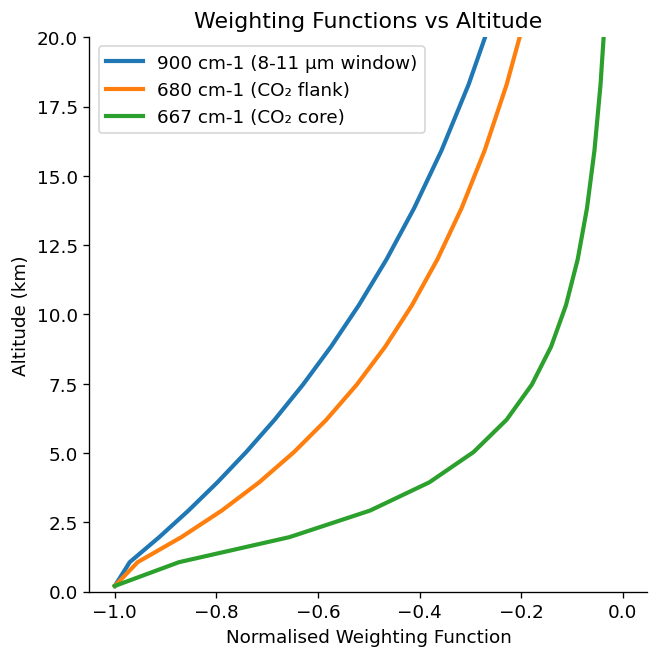

In [13]:
fig, ax_wf = plt.subplots(figsize=(6, 6))

for (ch_name, (nu_ch, k_abs_col)), col in zip(channels.items(), colors_ch):

    k_profile = k_abs_col * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_profile = np.exp(-tau_cum[::-1])

    dt_dp = np.gradient(t_profile, p_levels)

    wf_raw = -dt_dp
    wf = wf_raw / (np.max(np.abs(wf_raw)) + 1e-12)

    ax_wf.plot(wf, z_approx, lw=2.5, label=ch_name)

ax_wf.set_xlabel("Normalised Weighting Function")
ax_wf.set_ylabel("Altitude (km)")
ax_wf.set_title("Weighting Functions vs Altitude")
ax_wf.set_ylim(0, 20)
ax_wf.legend()

# save figure
plt.savefig("weighting_function_altitude.png", dpi=150, bbox_inches="tight")

plt.show()

## 1.4 Jacobians — The Bridge to Bayesian Retrieval

The Jacobian:

$$K_{ij} = \frac{\partial y_i}{\partial x_j}$$

tells us how sensitive measurement i is to state variable j. This is the key matrix that connects the forward model to the Bayesian update:

$$\hat{x} = x_a + G(y - F(x_a))$$  where  $$G = S_a K^T(K S_a K^T + S_\varepsilon)^{-1}$$

A large $|K_{ij}|$ means the measurement is sensitive to that state variable
→ the posterior will be much narrower than the prior for that variable.


--- 
For example, if we want to compute the temperature jacobian: 

$$K(\nu,p) = \frac{\partial BT(\nu)}{\partial T(p)}$$

which tells us **how sensitive the observed brightness temperature at a given spectral channel is to temperature at each pressure level**. This is the core idea behind **satellite temperature sounding retrievals**.

In the above equation:
- $i \rightarrow $ spectral channel
- $j \rightarrow $ pressure level i.e. how many pressure levels are considered.

Numerically we compute $K_{ij}$ as:

$$
K_{ij} = \approx \frac{BT_i(T_j + \Delta T) - BY_i(T_j)}{\Delta T}
$$

So once, we calculate it the final strucutre of $K$ looks like:

$$
K =
\begin{bmatrix}
\frac{\partial BT(\nu_1)}{\partial T(p_1)} & \cdots & \frac{\partial BT(\nu_1)}{\partial T(p_n)} \\
\vdots & & \vdots \\
\frac{\partial BT(\nu_m)}{\partial T(p_1)} & \cdots & \frac{\partial BT(\nu_m)}{\partial T(p_n)}
\end{bmatrix}
$$

and it tells us which atmoshpheric layers influence that channel. For example for CO$_2$, 667 cm$^{-1}$ has a sensitivity at upper atmosphere. However for 900-1000 cm$^{-1}$, sensitivity at surface.

**Why this matrix is important?:** This is used in 

$$y=F(x) \Rightarrow y \approx F(x_0) + K(x-x_0),$$

where 
- $y\rightarrow$ observed radiances,  
- $x\rightarrow$ temperature profile and
-  $K \rightarrow$ sensitivity matrix

This is the foundation of optimal estimation, variational data assimilation, Satellite retrieval algorithms.

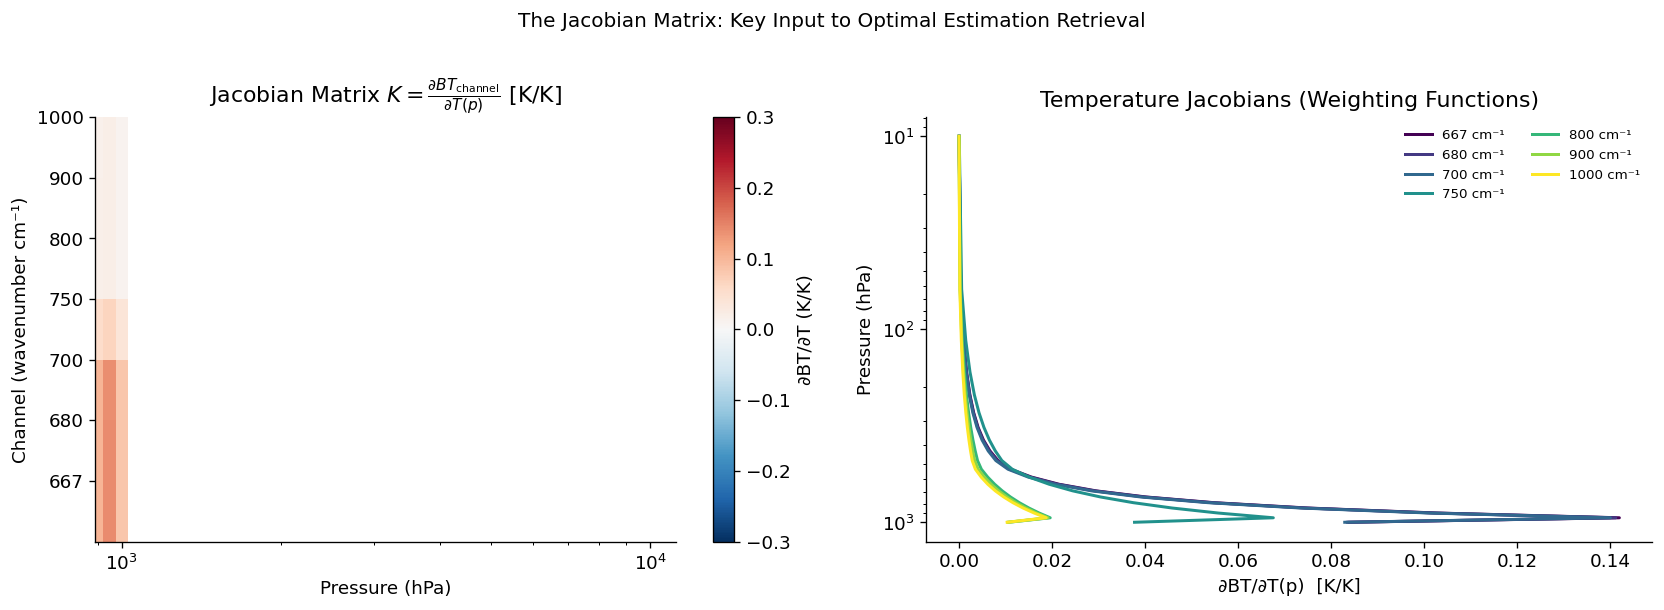

Jacobian shape: (7, 20) (channels × pressure levels)
The retrieval can only determine ~d_s independent combinations of the profile,
where d_s = trace(A) = trace(Sa K^T Se^{-1} K) is the degrees of freedom for signal.


In [5]:
# Jacobian dBT/dT(p): how does each pressure level's temperature affect each channel BT?
nu_channels = np.array([667, 680, 700, 750, 800, 900, 1000])
ch_labels   = [f"{nu}" for nu in nu_channels]

n_ch = len(nu_channels)
n_p  = len(p_levels)
K    = np.zeros((n_ch, n_p))             # initializing the matrix with dimention n_ch x n_p

delta_T = 1.0   # 1K perturbation

for i, nu_ch in enumerate(nu_channels):

    # --- Build absorption profile ---
    k_col = 0.5 if nu_ch > 750 else (2.0 if nu_ch > 700 else 5.0)
    k_profile = k_col * p_levels / 1013.0
    dp = np.diff(p_levels, prepend=p_levels[0])
    tau_cum = np.cumsum(k_profile * np.abs(dp) / 1013.0)[::-1]
    t_p = np.exp(-tau_cum[::-1])

    # --- Loop over pressure levels ---
    for j in range(n_p):

        # Perturb temperature at level j
        T_pert = T_std.copy()
        T_pert[j] += delta_T

        # Radiance (base and perturbed)
        B_atm_pert = planck(nu_ch, T_pert)
        B_atm_base = planck(nu_ch, T_std)

        I_base = planck(nu_ch, 295)*t_p[0] + np.trapezoid(B_atm_base*(-np.gradient(t_p,p_levels)), p_levels)
        I_pert = planck(nu_ch, 295)*t_p[0] + np.trapezoid(B_atm_pert*(-np.gradient(t_p,p_levels)), p_levels)

        BT_base = rad_to_BT(nu_ch, I_base)
        BT_pert = rad_to_BT(nu_ch, I_pert)
        K[i, j] = (BT_pert - BT_base) / delta_T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].pcolormesh(p_levels, np.arange(n_ch), K, cmap="RdBu_r", vmin=-0.3, vmax=0.3)
axes[0].set_xlabel("Pressure (hPa)")
axes[0].set_ylabel("Channel (wavenumber cm⁻¹)")
axes[0].set_yticks(np.arange(n_ch)+0.5)
axes[0].set_yticklabels(ch_labels)
axes[0].set_xscale("log")
axes[0].set_title(r"Jacobian Matrix $K = \frac{\partial BT_{\mathrm{channel}}}{\partial T(p)}$ [K/K]")
plt.colorbar(im, ax=axes[0], label="∂BT/∂T (K/K)")

# Individual weighting functions per channel
for i, (nu_ch, col) in enumerate(zip(nu_channels, plt.cm.viridis(np.linspace(0,1,n_ch)))):
    axes[1].plot(K[i], p_levels, color=col, lw=1.8, label=f"{nu_ch} cm⁻¹")

axes[1].invert_yaxis()
axes[1].set_yscale("log")
axes[1].set_xlabel("∂BT/∂T(p)  [K/K]")
axes[1].set_ylabel("Pressure (hPa)")
axes[1].set_title("Temperature Jacobians (Weighting Functions)")
axes[1].legend(frameon=False, fontsize=8, ncol=2)

plt.suptitle("The Jacobian Matrix: Key Input to Optimal Estimation Retrieval",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Jacobian shape:", K.shape, "(channels × pressure levels)")
print("The retrieval can only determine ~d_s independent combinations of the profile,")
print("where d_s = trace(A) = trace(Sa K^T Se^{-1} K) is the degrees of freedom for signal.")


In [13]:
print("Chapter 1 complete!")
print()
print("Summary of the forward model:")
print("  y = F(x) + ε")
print("  y: measured BTs or reflectances")
print("  x: atmospheric state (T, gases, aerosols, surface)")
print("  F: radiative transfer (Beer-Lambert + Planck emission)")
print("  ε: instrument noise ~ N(0, Sε)")
print()
print("Key physics:")
print("  - Weighting function peaks at τ ≈ 1")
print("  - Window channels see the surface")
print("  - CO₂ core channel sees the stratosphere")
print("  - Different channels = independent information = vertical resolution")


Chapter 1 complete!

Summary of the forward model:
  y = F(x) + ε
  y: measured BTs or reflectances
  x: atmospheric state (T, gases, aerosols, surface)
  F: radiative transfer (Beer-Lambert + Planck emission)
  ε: instrument noise ~ N(0, Sε)

Key physics:
  - Weighting function peaks at τ ≈ 1
  - Window channels see the surface
  - CO₂ core channel sees the stratosphere
  - Different channels = independent information = vertical resolution
